In [1]:
import matplotlib.pyplot as plt
import sys

%matplotlib widget

In [92]:
sys.path.insert(0, '/home/ssilburn/Python/')

In [3]:
from mraw_reader import MRAWReader as mrr

In [4]:
R = mrr('/common/BES_analysis/raw/45327.mraw')

In [38]:
R.set_frame_time(0.785)
R.set_frame_time(0.51)

In [39]:
frame, info = R.read()

In [95]:
info

{'size': 233472, 'time_stamp': 0.510011574074074}

Text(0.5, 1.0, '0.5100347222222222')

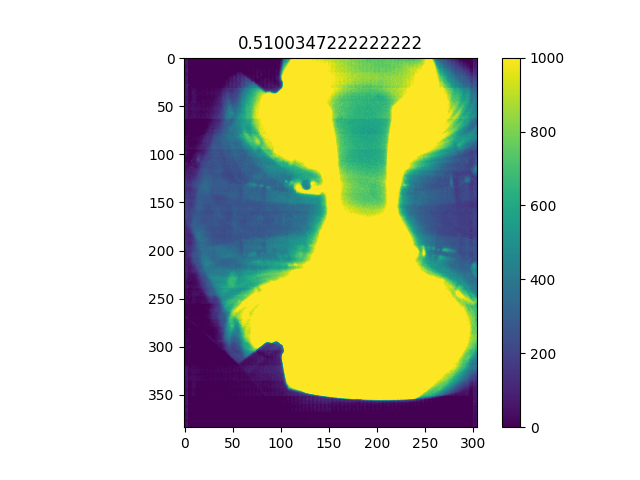

In [98]:
frame, info = R.read()
plt.figure()
plt.imshow(frame, vmin=0., vmax=1000)
plt.colorbar()
plt.title(info['time_stamp'])

In [24]:
import pyuda
import numpy as np
client = pyuda.Client()

In [25]:
shotn = 50499
T0 = 500
_data = client.get_images('rba', shotn, frame_number=T0)

I = _data.right + 1 - _data.left
J = _data.bottom + 1 - _data.top
dtype = _data.frames[0].k.dtype
time = _data.frame_times[T0]

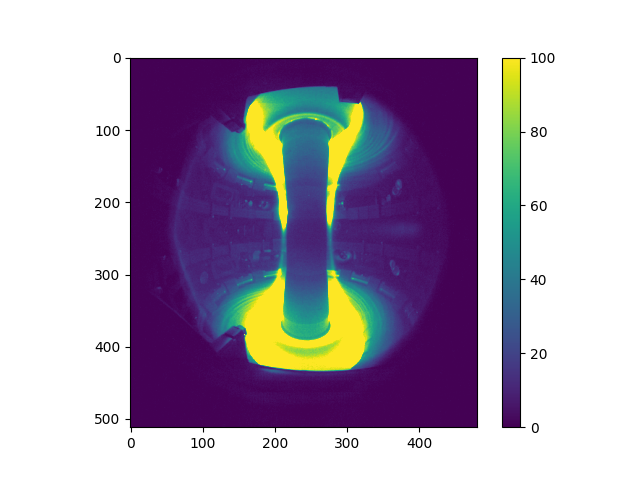

In [26]:
plt.figure()
plt.imshow(_data.frames[0].k.T[:,::-1], vmin=0, vmax=100.)
plt.colorbar()

In [27]:
_data.right, _data.left, _data.bottom, _data.top

(768, 257, 752, 273)

In [43]:
frame.shape

(384, 304)

In [44]:
data.shape

(1024, 1024)

In [46]:
(1024//2) - (384//2), (1024//2) + (384//2)

(320, 704)

In [47]:
(1024//2) - (304//2), (1024//2) + (304//2)

(360, 664)

In [64]:
data[320:704,360:664].shape

(384, 304)

Text(0.5, 1.0, '(384, 304)')

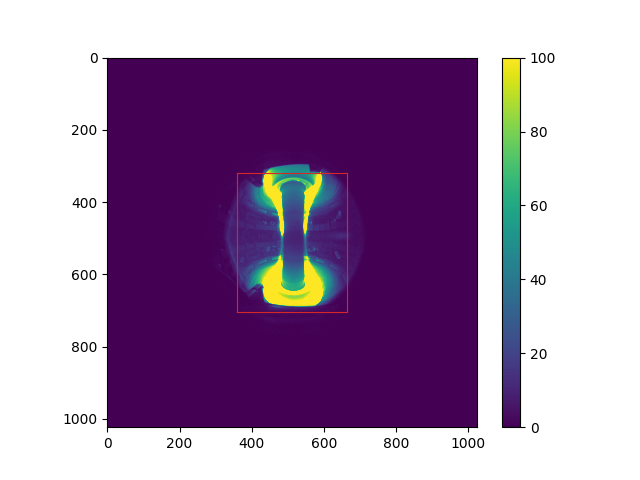

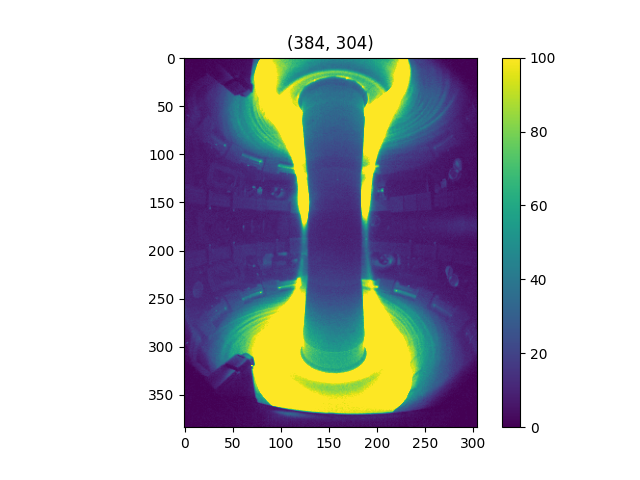

In [73]:
data = np.zeros((1024,1024))
# data2 = np.zeros((1024,1024))
data2 = np.zeros_like(frame)
data[273-1:752,257-1:768] = _data.frames[0].k
data = data.T
data = data[:,::-1]

# data2[:,:] = data[1024-360:1024-704,1024-]

plt.figure()
plt.imshow(data, vmin=0, vmax=100.)
plt.colorbar()
plt.plot([1024-664,1024-664], [1024-320,1024-704], '-', c='C3', lw=0.8)
plt.plot([1024-360,1024-360], [1024-320,1024-704], '-', c='C3', lw=0.8)
plt.plot([1024-360,1024-664], [1024-320,1024-320], '-', c='C3', lw=0.8)
plt.plot([1024-360,1024-664], [1024-704,1024-704], '-', c='C3', lw=0.8)

plt.figure()
plt.imshow(data[1024-704:1024-320, 1024-664:1024-360], vmin=0, vmax=100.)
plt.colorbar()
plt.title(f'{data[1024-704:1024-320, 1024-664:1024-360].shape}')

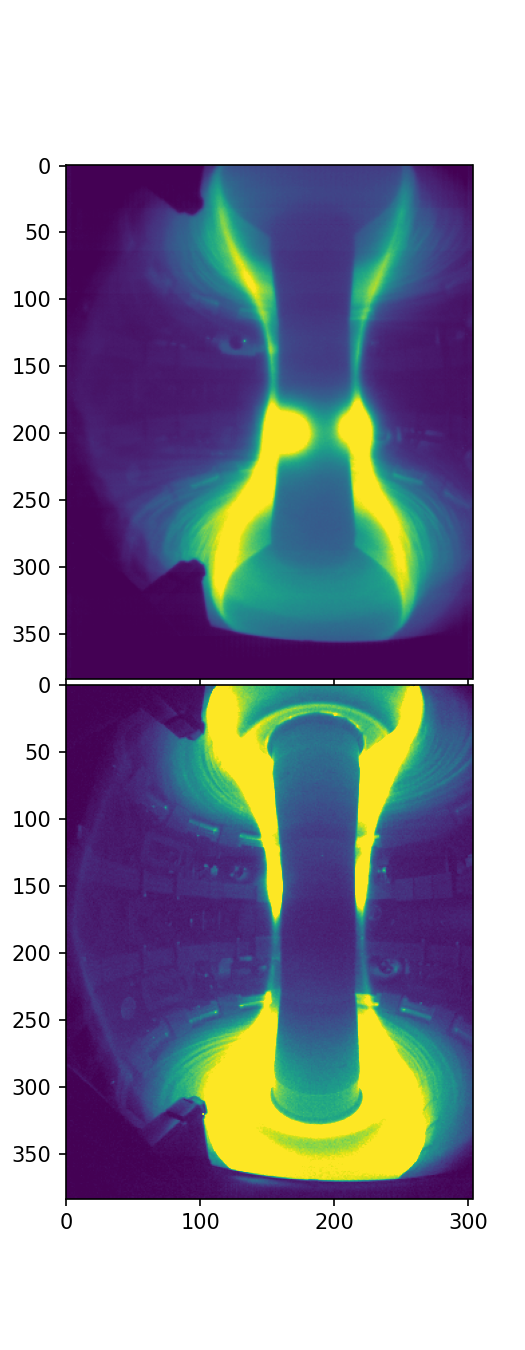

In [94]:
I0 = 1024-704
I1 = 1024-320

dJ = -32
# dJ = 0

J0 = 1024-664 + dJ
J1 = 1024-360 + dJ

fig, ax = plt.subplots(2,1, figsize=(3.5,9), dpi=150, sharex=True, sharey=True)
plt.subplots_adjust(hspace=0, wspace=0)
ax[0].imshow(frame, vmin=0, vmax=4095)
ax[1].imshow(data[I0:I1,J0:J1], vmin=0, vmax=100.)

In [77]:
top frame
40 : 294

bottom frame
42: 306

(384, 304)

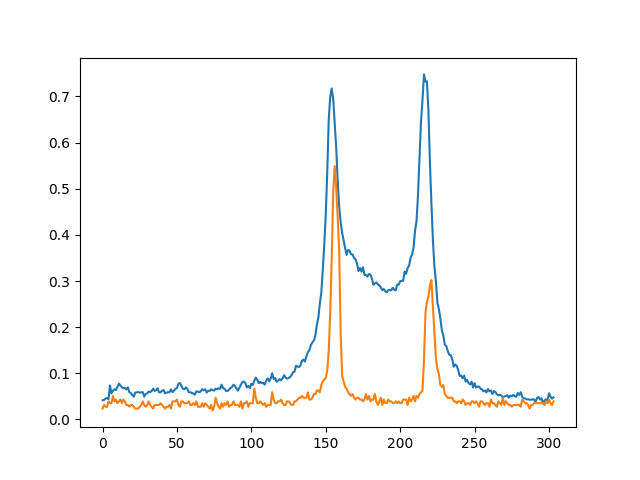

In [91]:
plt.figure()
plt.plot(frame[170]/frame.max())
plt.plot(data[I0:I1,J0:J1][170] / data[I0:I1,J0:J1].max())

In [88]:
frame.max()

4095

In [89]:
4096/256

16.0

In [90]:
2**4

16